In [119]:
import sys
import subprocess

# Auto-install pygam jika belum ada
try:
    import pygam
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pygam"])

# Auto-install dmba jika belum ada
try:
    import dmba
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "dmba"])

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import linregress
import seaborn as sns

# Statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.gam.api import BSplines, GLMGam
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.outliers_influence import OLSInfluence

# Scikit-Learn
from sklearn.linear_model import (
    Lasso,
    LassoCV,
    LassoLars,
    LassoLarsCV,
    LinearRegression,
)
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# PyGAM & DMBA
from pygam import LinearGAM, l, s
from pygam.datasets import wage
from dmba import AIC_score, stepwise_selection

In [120]:
URL_LUNG = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/LungDisease.csv"
URL_HOUSE = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/house_sales.csv"

lung = pd.read_csv(URL_LUNG)
house = pd.read_csv(URL_HOUSE, sep="\t")

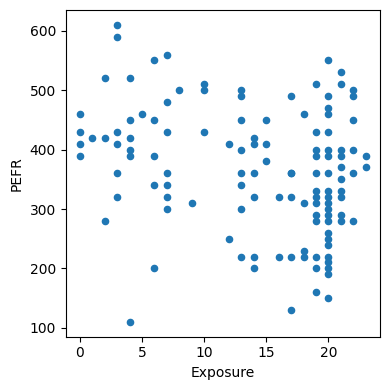

In [121]:
fig, ax = plt.subplots(figsize=(4, 4))
lung.plot.scatter(x="Exposure", y="PEFR", ax=ax)
plt.tight_layout()
plt.show()

In [122]:
predictors = ["Exposure"]
outcome = "PEFR"

model_lung = LinearRegression()
model_lung.fit(lung[predictors], lung[outcome])

print("=== Simple Linear Regression (Lung Disease) ===")
print(f"Intercept (b0): {model_lung.intercept_:.3f}")
print(f"Coefficient Exposure (b1): {model_lung.coef_[0]:.3f}\n")

=== Simple Linear Regression (Lung Disease) ===
Intercept (b0): 424.583
Coefficient Exposure (b1): -4.185



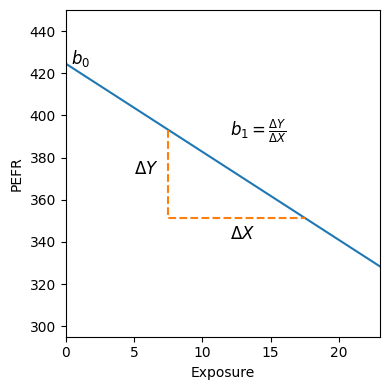

In [123]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(0, 23)
ax.set_ylim(295, 450)
ax.set_xlabel("Exposure")
ax.set_ylabel("PEFR")
ax.plot((0, 23), model_lung.predict(pd.DataFrame({"Exposure": [0, 23]})))
ax.text(0.4, model_lung.intercept_, r"$b_0$", size="larger")

x_points = pd.DataFrame({"Exposure": [7.5, 17.5]})
y_points = model_lung.predict(x_points)
ax.plot((7.5, 7.5, 17.5), (y_points[0], y_points[1], y_points[1]), "--")
ax.text(5, np.mean(y_points), r"$\Delta Y$", size="larger")
ax.text(12, y_points[1] - 10, r"$\Delta X$", size="larger")
ax.text(12, 390, r"$b_1 = \frac{\Delta Y}{\Delta X}$", size="larger")

plt.tight_layout()
plt.show()

In [124]:
fitted = model_lung.predict(lung[predictors])
residuals = lung[outcome] - fitted

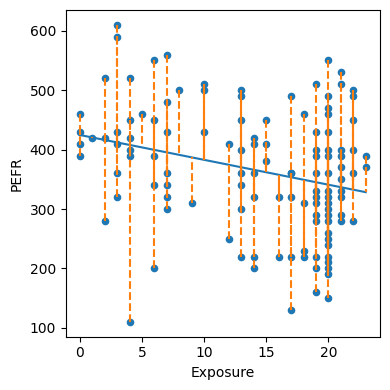

In [125]:
fig, ax = plt.subplots(figsize=(4, 4))
lung.plot.scatter(x="Exposure", y="PEFR", ax=ax)
ax.plot(lung.Exposure, fitted)
for x_val, yactual, yfitted in zip(lung.Exposure, lung.PEFR, fitted):
    ax.plot((x_val, x_val), (yactual, yfitted), "--", color="C1")

plt.tight_layout()
plt.show()

In [126]:
subset = [
    "AdjSalePrice",
    "SqFtTotLiving",
    "SqFtLot",
    "Bathrooms",
    "Bedrooms",
    "BldgGrade",
]

In [127]:
predictors = ["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade"]
outcome = "AdjSalePrice"

house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])

print("=== Multiple Linear Regression (House Sales) ===")
print(f"Intercept: {house_lm.intercept_:.3f}")
print("Coefficients:")
for name, coef in zip(predictors, house_lm.coef_):
    print(f"  {name}: {coef:.3f}")

=== Multiple Linear Regression (House Sales) ===
Intercept: -521871.368
Coefficients:
  SqFtTotLiving: 228.831
  SqFtLot: -0.060
  Bathrooms: -19442.840
  Bedrooms: -47769.955
  BldgGrade: 106106.963


Intercept (-521,871.368). The intercept is the baseline value of the predicted property price when all the features are zero.

A negative intercept suggests that if all features were zero (which might not be realistic in this context), the model predicts a negative property price. This usually indicates that the model might need adjustments or that other important features are missing.

Each coefficient represents how much the predicted property price changes with a one-unit increase in that feature, assuming all other features remain constant.
1. SqFtTotLiving (228.83). For every additional square foot of total living space, the property price increases by approximately 228.83 units of your currency.
2. SqFtLot (-0.06). For every additional square foot of the lot size, the property price decreases by approximately 0.06 units of your currency.
3. Bathrooms (-19,442.84). For each additional bathroom, the property price decreases by approximately 19,442.84 units of your currency.
4. Bedrooms (-47,769.96). For each additional bedroom, the property price decreases by approximately 47,769.96 units of your currency.
5. BldgGrade (106,106.96). For each one-point increase in the building grade, the property price increases by approximately 106,106.96 units of your currency.

**Summary**
1. Positive Coefficients: SqFtTotLiving and BldgGrade positively influence the property price, meaning more living space and higher building quality increase the price.
2. Negative Coefficients: SqFtLot, Bathrooms, and Bedrooms negatively influence the property price in this model, which is unusual and suggests that there might be underlying factors or issues with the data/model that need further investigation.

In [128]:
fitted_house = house_lm.predict(house[predictors])
rmse = np.sqrt(mean_squared_error(house[outcome], fitted_house))
r2 = r2_score(house[outcome], fitted_house)
print(f"\nRMSE: {rmse:.0f}")
print(f"R2  : {r2:.4f}\n")


RMSE: 261220
R2  : 0.5406



A. Akaike Information Criterion (AIC)
* Definition: AIC is a measure used to compare different statistical models and determine which one best explains the data without overfitting. It assesses the trade-off between the goodness of fit of the model and the number of parameters used.

* Purpose: To identify the model that best balances complexity and accuracy. Lower AIC values indicate a better model.

B. Bayesian Information Criterion (BIC)
* Definition: BIC is similar to AIC but incorporates a stronger penalty for models with more parameters. It is also used for model selection, emphasizing the balance between model fit and simplicity.

* Purpose: To select the model that is most likely to be the true model among the candidate models, especially in larger datasets. Lower BIC values indicate a better model.


A. **AIC Formula**

$$
\text{AIC} = 2k - 2\ln(L)
$$

**Where:**
\begin{align*}
k &= \text{Number of parameters in the model} \\
L &= \text{Maximum value of the likelihood function for the model}
\end{align*}

---

B. **BIC Formula**

$$
\text{BIC} = \ln(n) \cdot k - 2\ln(L)
$$

**Where:**
\begin{align*}
n &= \text{Number of observations} \\
k &= \text{Number of parameters in the model} \\
L &= \text{Maximum value of the likelihood function for the model}
\end{align*}



---

Understanding the Components
A. of Parameters ($k$)
* Definition: The total count of estimated parameters in the model, including the intercept.
* Implication: More parameters can lead to a better fit but may cause overfitting.

B. Likelihood Function ($L$)
* Definition: Represents the probability of observing the given data under the specified model.
* Implication: A higher likelihood indicates a better fit to the data.
C. Number of Observations ($n$)
(Only in BIC)
* Definition: The total number of data points used in the model.
* Implication: Larger datasets can influence the penalty term in BIC, making it more stringent.



How to Use AIC and BIC
A. Model Comparison
1. Calculate AIC and BIC for each candidate model.
2. Compare the Values:
* Lower AIC/BIC: Indicates a better model considering both fit and complexity.
* Difference in Values: AIC differences >10 are considered substantial; for BIC, differences >6 are significant.
B. Selection Criteria
* AIC:
1. Focuses on the model's predictive accuracy.

2. More suitable when the goal is to predict future data points.

* BIC:
1. Emphasizes model simplicity.

2. Preferred when the goal is to identify the true model among candidates, especially with larger datasets.


In [129]:
model_ols = sm.OLS(house[outcome], house[predictors].assign(const=1))
results_ols = model_ols.fit()
print("=== OLS Summary (Base Predictors) ===")
print(results_ols.summary())

=== OLS Summary (Base Predictors) ===
                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        11:59:02   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotL

In [130]:
full_predictors = [
    "SqFtTotLiving",
    "SqFtLot",
    "Bathrooms",
    "Bedrooms",
    "BldgGrade",
    "PropertyType",
    "NbrLivingUnits",
    "SqFtFinBasement",
    "YrBuilt",
    "YrRenovated",
    "NewConstruction",
]

X_full = pd.get_dummies(house[full_predictors], drop_first=True, dtype=int)
X_full["NewConstruction"] = [
    1 if nc else 0 for nc in X_full["NewConstruction"]
]
y_house = house[outcome]

house_full_ols = sm.OLS(y_house, X_full.assign(const=1))
results_full = house_full_ols.fit()
print("\n=== OLS Summary (Full Features) ===")
print(results_full.summary())


=== OLS Summary (Full Features) ===
                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     2771.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        11:59:02   Log-Likelihood:            -3.1375e+05
No. Observations:               22687   AIC:                         6.275e+05
Df Residuals:                   22674   BIC:                         6.276e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

1. SqFtTotLiving
* coef: 198.6364 → For each additional
square foot of living space, the property price increases by $198.64.

* std err: 4.234 → The level of uncertainty is small, meaning the coefficient estimate is quite accurate.

* t: 46.920 → The t-statistic value is very large, indicating a highly significant effect.

* P>|t|: 0.000 → Statistically significant (p-value is well below 0.05).

* [0.025, 0.975]: [190.338, 206.934] → The confidence interval shows that the coefficient value is almost certainly within this range. -- We can be 95% confident that each additional square foot of living space increases the property price by between 190.34 and 206.93.



2. SqFtLot
* coef: 0.0771 → For each additional square foot of lot size, the property price increases by $0.0771.

* std err: 0.058 → The level of uncertainty is moderate, indicating that the coefficient estimate is somewhat less precise.

* t: 1.330 → The t-statistic value is small, suggesting a weak effect.

* P>|t|: 0.184 → Not statistically significant (p-value is greater than 0.05).

* [0.025, 0.975]: [-0.037, 0.191] → The confidence interval includes zero, meaning that the effect of SqFtLot on price might be nonexistent. -- Since the confidence interval includes zero, it suggests that the effect of lot size on property price could be positive, negative, or nonexistent. This further indicates uncertainty about the true impact of lot size on the property's price.

3. Bathrooms
* coef: 42860 → Each additional bathroom increases the price by $42,860.

* std err: 3808.114 → The level of uncertainty is relatively small compared to the coefficient value.

* t: 11.255 → A large t-statistic indicates a significant effect.

* P>|t|: 0.000 → Highly statistically significant (p-value well below 0.05).

* [0.025, 0.975]: [35400, 50300] → A narrow range confirming a positive significant effect. -- We can be 95% confident that each additional bathroom increases the property price by between 35,400 and 50,300. The narrow interval reinforces the precision and reliability of the coefficient estimate.

4. Bedrooms
* coef: -51,870 → Each additional bedroom decreases the price by $51,870.

* std err: 2,396.904 → The standard error is small, indicating the coefficient estimate is quite accurate.

* t: -21.638 → A very large (negative) t-statistic value, indicating a significant effect.

* P>|t|: 0.000 → Highly statistically significant (p-value well below 0.05).

* [0.025, 0.975]: [-56,600, -47,200] → This confidence interval does not include zero, confirming a negative effect.


-- **the list go on based on data above**

Overall Implications
- The regression analysis provides clear insights into the factors that significantly influence property prices:

Key Drivers of Higher Property Prices:

* Total Living Area (SqFtTotLiving): Emphasizes the importance of spaciousness.
* Number of Bathrooms: Highlights the premium on functional amenities.
* Building Grade (BldgGrade): Underscores the value of construction quality and aesthetics.

Factors Leading to Lower Property Prices:

* Number of Bedrooms: Suggests a complex relationship where more bedrooms may not equate to higher value, possibly due to layout or other underlying factors.
* Year Built (YrBuilt): Indicates that older properties might be valued higher, potentially due to historical or locational advantages.

Non-Influential Factors:

* Lot Size, Number of Living Units, Finished Basement Area, Year Renovated, New Construction: These factors do not significantly impact property prices, suggesting that buyers prioritize other aspects over these features.

Recommendations for Further Analysis:

* Investigate the Negative Impact of Bedrooms: Understanding why more bedrooms lead to lower prices could uncover underlying issues such as inefficient layouts or market preferences.

* Explore the Role of Year Built: Delving deeper into why older properties are valued higher could provide insights into market trends and historical property advantages.

* Assess Non-Significant Variables: While these factors were not significant in this analysis, their impact might vary in different markets or with additional variables considered.

In [131]:
def train_model(variables):
    if len(variables) == 0:
        return None
    m = LinearRegression()
    m.fit(X_full[variables], y_house)
    return m


def score_model(m, variables):
    if len(variables) == 0:
        return AIC_score(
            y_house, [y_house.mean()] * len(y_house), m, df=1
        )
    return AIC_score(y_house, m.predict(X_full[variables]), m)


best_model, best_variables = stepwise_selection(
    X_full.columns, train_model, score_model, verbose=True
)

print("\n=== Best Model from Stepwise Selection ===")
print(f"Intercept: {best_model.intercept_:.3f}")
print("Coefficients:")
for name, coef in zip(best_variables, best_model.coef_):
    print(f"  {name}: {coef:.3f}\n")

Variables: SqFtTotLiving, SqFtLot, Bathrooms, Bedrooms, BldgGrade, NbrLivingUnits, SqFtFinBasement, YrBuilt, YrRenovated, NewConstruction, PropertyType_Single Family, PropertyType_Townhouse
Start: score=647988.32, constant
Step: score=633013.35, add SqFtTotLiving
Step: score=630793.74, add BldgGrade
Step: score=628230.29, add YrBuilt
Step: score=627784.16, add Bedrooms
Step: score=627602.21, add Bathrooms
Step: score=627525.65, add PropertyType_Townhouse
Step: score=627525.08, add SqFtFinBasement
Step: score=627524.98, add PropertyType_Single Family
Step: score=627524.98, unchanged None

=== Best Model from Stepwise Selection ===
Intercept: 6178645.017
Coefficients:
  SqFtTotLiving: 199.278

  BldgGrade: 137159.560

  YrBuilt: -3565.425

  Bedrooms: -51947.384

  Bathrooms: 42396.165

  PropertyType_Townhouse: 84479.162

  SqFtFinBasement: 7.047

  PropertyType_Single Family: 22912.055



* Interpretation:
1. Start: The model begins with no predictors, achieving an AIC score of 647,988.32.
2. Subsequent Steps: Variables are added one by one in the order that most reduces the AIC score:
* SqFtTotLiving: Adds significant improvement, reducing the score to 633,013.35.
* BldgGrade: Further reduces the score to 630,793.74.
* YrBuilt: Continues the improvement to 628,230.29.
* Bedrooms: Reduces the score to 627,784.16.
* Bathrooms: Brings the score down to 627,602.21.
* PropertyType_Townhouse: Improves the score to 627,525.65.
* SqFtFinBasement: Slightly reduces the score to 627,525.08.
* PropertyType_Single Family: Final addition brings the score to 627,524.98.

3. Termination: No further variables improve the AIC score, so the selection process stops.

In [132]:
house["Year"] = house.DocumentDate.apply(lambda d: int(d.split("-")[0]))
house["Weight"] = house.Year - 2005

house_wt = LinearRegression()
house_wt.fit(
    house[predictors], house[outcome], sample_weight=house["Weight"]
)

LinearRegression()

In [133]:
df_coef_comp = pd.concat(
    [
        pd.DataFrame(
            {
                "predictor": predictors,
                "house_lm": house_lm.coef_,
                "house_wt": house_wt.coef_,
            }
        ),
        pd.DataFrame(
            {
                "predictor": ["intercept"],
                "house_lm": [house_lm.intercept_],
                "house_wt": [house_wt.intercept_],
            }
        ),
    ]
).reset_index(drop=True)

print("=== Comparison: Standard LM vs Weighted LM ===")
print(df_coef_comp)

=== Comparison: Standard LM vs Weighted LM ===
       predictor       house_lm       house_wt
0  SqFtTotLiving     228.830604     245.024089
1        SqFtLot      -0.060467      -0.292415
2      Bathrooms  -19442.840398  -26085.970109
3       Bedrooms  -47769.955185  -53608.876436
4      BldgGrade  106106.963079  115242.434726
5      intercept -521871.368188 -584189.329446


1. Predictor Coefficients:

* house_lm: Represents the impact of each predictor on the sale price without weighting.
* house_wt: Represents the impact when newer data points are given more importance.

2. Interpretation:

* SqFtTotLiving: Both models agree that larger living areas increase the sale price, with the weighted model showing a slightly higher impact.
* SqFtLot: Larger lot sizes slightly decrease the sale price in both models, more so in the weighted model.
* Bathrooms & Bedrooms: Surprisingly, both models show negative coefficients, suggesting that more bathrooms or bedrooms are associated with lower sale prices. This might indicate multicollinearity or data issues.
* BldgGrade: Higher building grades significantly increase the sale price in both models, with the weighted model showing a stronger effect.
* Intercept: The base sale price is lower in the weighted model, reflecting the influence of newer data.


In [134]:
residuals_df = pd.DataFrame(
    {
        "abs_residual_lm": np.abs(
            house_lm.predict(house[predictors]) - house[outcome]
        ),
        "abs_residual_wt": np.abs(
            house_wt.predict(house[predictors]) - house[outcome]
        ),
        "Year": house["Year"],
    }
)

mean_abs_res_per_year = pd.DataFrame(
    [
        [
            year,
            np.mean(group["abs_residual_lm"]),
            np.mean(group["abs_residual_wt"]),
        ]
        for year, group in residuals_df.groupby("Year")
    ],
    columns=["Year", "mean abs_residual_lm", "mean abs_residual_wt"],
)

print("\n=== Mean Absolute Residuals by Year ===")
print(mean_abs_res_per_year)


=== Mean Absolute Residuals by Year ===
   Year  mean abs_residual_lm  mean abs_residual_wt
0  2006         140540.303585         146557.454636
1  2007         147747.577959         152848.523235
2  2008         142086.905943         146360.411668
3  2009         147016.720883         151182.924825
4  2010         163267.674885         166364.476152
5  2011         169937.385744         172950.876028
6  2012         169506.670053         171874.424266
7  2013         203659.777510         206242.199403
8  2014         184452.840665         186668.573750
9  2015         172323.435147         169842.742053


**Factor variables in regression**

**Dummy Variables Representation**

In [135]:
print("\n=== PropertyType Head (Original) ===")
print(house.PropertyType.head(5))


=== PropertyType Head (Original) ===
1        Multiplex
2    Single Family
3    Single Family
4    Single Family
5    Single Family
Name: PropertyType, dtype: object


In [136]:
print("\n=== PropertyType Head (One-Hot Encoded, drop_first=True) ===")
print(pd.get_dummies(house["PropertyType"], drop_first=True).head(5))


=== PropertyType Head (One-Hot Encoded, drop_first=True) ===
   Single Family  Townhouse
1          False      False
2           True      False
3           True      False
4           True      False
5           True      False


In [137]:
zip_residuals = pd.DataFrame(
    {
        "ZipCode": house["ZipCode"],
        "residual": house[outcome] - house_lm.predict(house[predictors]),
    }
)

zip_groups = pd.DataFrame(
    [
        {
            "ZipCode": zip_code,
            "count": len(x),
            "median_residual": x.residual.median(),
        }
        for zip_code, x in zip_residuals.groupby("ZipCode")
    ]
).sort_values("median_residual")

zip_groups["cum_count"] = np.cumsum(zip_groups["count"])
zip_groups["ZipGroup"] = pd.qcut(
    zip_groups["cum_count"], 5, labels=False, retbins=False
)

if "ZipGroup" in house.columns:
    house = house.drop(columns=["ZipGroup"])

to_join = zip_groups[["ZipCode", "ZipGroup"]].set_index("ZipCode")
house = house.join(to_join, on="ZipCode")
house["ZipGroup"] = house["ZipGroup"].astype("category")

# Confounding Regression
predictors_confounding = [
    "SqFtTotLiving",
    "SqFtLot",
    "Bathrooms",
    "Bedrooms",
    "BldgGrade",
    "PropertyType",
    "ZipGroup",
]

X_confounding = pd.get_dummies(
    house[predictors_confounding], drop_first=True
)

confounding_lm = LinearRegression()
confounding_lm.fit(X_confounding, house[outcome])

print("\n=== Coefficients with ZipGroup Included (Confounding) ===")
print(f"Intercept: {confounding_lm.intercept_:.3f}")
for name, coef in zip(X_confounding.columns, confounding_lm.coef_):
    print(f"  {name}: {coef:.3f}")


=== Coefficients with ZipGroup Included (Confounding) ===
Intercept: -666637.469
  SqFtTotLiving: 210.613
  SqFtLot: 0.455
  Bathrooms: 5928.426
  Bedrooms: -41682.872
  BldgGrade: 98541.184
  PropertyType_Single Family: 19323.625
  PropertyType_Townhouse: -78198.721
  ZipGroup_1: 53317.173
  ZipGroup_2: 116251.589
  ZipGroup_3: 178360.532
  ZipGroup_4: 338408.602


3. Theoretical Justification for Reducing to 𝑃−1 Columns
By dropping one dummy variable (typically using the drop_first=True parameter in functions like pd.get_dummies), you:

* Establish a Reference Category: The omitted category serves as the baseline against which the other categories are compared.
* Eliminate Redundancy: With 𝑃−1 dummy variables, the intercept captures the effect of the reference category, and each remaining dummy variable captures the deviation from this baseline.
* Ensure Model Identifiability: Removing one dummy variable resolves the linear dependency, making the design matrix full rank and ensuring that the regression coefficients can be uniquely estimated.


INTERCATIONS AND MAIN EFFECTS


In [138]:
model_interaction = smf.ols(
    formula=(
        "AdjSalePrice ~ SqFtTotLiving*ZipGroup + SqFtLot + "
        "Bathrooms + Bedrooms + BldgGrade + PropertyType"
    ),
    data=house,
)
results_interaction = model_interaction.fit()
print("\n=== Interaction Model Summary ===")
print(results_interaction.summary())


=== Interaction Model Summary ===
                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     3247.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        11:59:03   Log-Likelihood:            -3.1098e+05
No. Observations:               22687   AIC:                         6.220e+05
Df Residuals:                   22671   BIC:                         6.221e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [139]:
predictors_confounding = [
    "SqFtTotLiving",
    "SqFtLot",
    "Bathrooms",
    "Bedrooms",
    "BldgGrade",
    "PropertyType",
    "ZipGroup",
]

X_confounding = pd.get_dummies(
    house[predictors_confounding], drop_first=True
)

confounding_lm = LinearRegression()
confounding_lm.fit(X_confounding, house[outcome])

print("\n=== Coefficients with ZipGroup Included (Confounding) ===")
print(f"Intercept: {confounding_lm.intercept_:.3f}")
for name, coef in zip(X_confounding.columns, confounding_lm.coef_):
    print(f"  {name}: {coef:.3f}")


=== Coefficients with ZipGroup Included (Confounding) ===
Intercept: -666637.469
  SqFtTotLiving: 210.613
  SqFtLot: 0.455
  Bathrooms: 5928.426
  Bedrooms: -41682.872
  BldgGrade: 98541.184
  PropertyType_Single Family: 19323.625
  PropertyType_Townhouse: -78198.721
  ZipGroup_1: 53317.173
  ZipGroup_2: 116251.589
  ZipGroup_3: 178360.532
  ZipGroup_4: 338408.602


**Testing the Assumptions: Regression Diagnostics**

In [140]:
house_98105 = house.loc[house["ZipCode"] == 98105].copy()

predictors_diag = [
    "SqFtTotLiving",
    "SqFtLot",
    "Bathrooms",
    "Bedrooms",
    "BldgGrade",
]
house_outlier = sm.OLS(
    house_98105[outcome], house_98105[predictors_diag].assign(const=1)
)
result_98105 = house_outlier.fit()

In [141]:
influence = OLSInfluence(result_98105)
sresiduals = influence.resid_studentized_internal

In [142]:
print("\n=== Outlier Analysis (Zipcode 98105) ===")
print(f"Min Studentized Residual Index: {sresiduals.idxmin()}")
print(f"Min Studentized Residual Value: {sresiduals.min():.4f}")


=== Outlier Analysis (Zipcode 98105) ===
Min Studentized Residual Index: 24333
Min Studentized Residual Value: -4.3267


**Influential values**

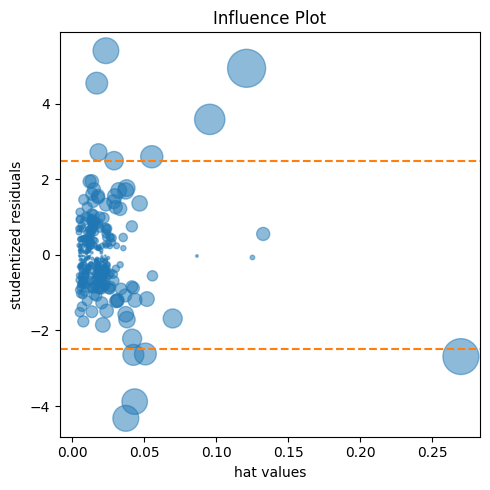

In [143]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.axhline(-2.5, linestyle="--", color="C1")
ax.axhline(2.5, linestyle="--", color="C1")
ax.scatter(
    influence.hat_matrix_diag,
    influence.resid_studentized_internal,
    s=1000 * np.sqrt(influence.cooks_distance[0]),
    alpha=0.5,
)
ax.set_xlabel("hat values")
ax.set_ylabel("studentized residuals")
ax.set_title("Influence Plot")
plt.tight_layout()
plt.show()

1. Interpretation:

* High Leverage Points:
Points on the far right (with high leverage values, e.g., >0.2) have a significant influence on the model.
Points located in the upper-right or lower-right areas with high residuals are usually considered observations that require special attention.

* Outliers:
Points outside the horizontal orange line represent unusual residuals (either too large or too small compared to predictions).
These observations may indicate statistical outliers.
Combination of High Leverage and High

* Residuals:
Points in the top-right or bottom-right corners (with both high leverage and high residuals) are usually considered problematic observations.
These points can significantly impact the model's estimations.

In [144]:
mask = [dist < 0.08 for dist in influence.cooks_distance[0]]
house_infl = house_98105.loc[mask]

ols_infl = sm.OLS(
    house_infl[outcome], house_infl[predictors_diag].assign(const=1)
)
result_infl = ols_infl.fit()

print("\n=== Parameters Comparison (Original vs Influential Removed) ===")
print(
    pd.DataFrame(
        {"Original": result_98105.params, "Influential removed": result_infl.params}
    )
)


=== Parameters Comparison (Original vs Influential Removed) ===
                    Original  Influential removed
SqFtTotLiving     209.602346           230.052569
SqFtLot            38.933315            33.141600
Bathrooms        2282.264145        -16131.879785
Bedrooms       -26320.268796        -22887.865318
BldgGrade      130000.099737        114870.559737
const         -772549.862447       -647137.096716


**Heteroskedasticity, Non-Normality and Correlated Errors**

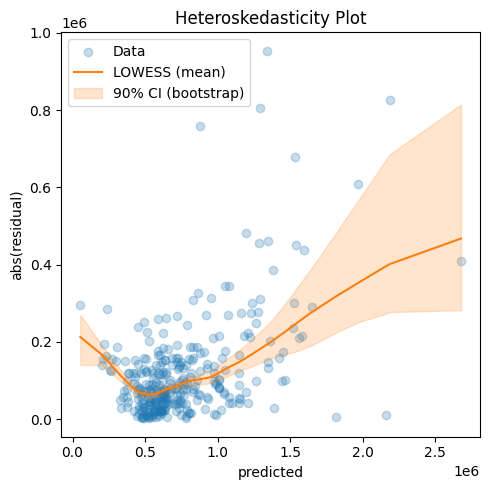

In [145]:
x_arr = result_98105.fittedvalues.values
y_arr = np.abs(result_98105.resid).values


def get_lowess_predictions(x_vals, y_vals, frac=0.5):
    idx_sorted = np.argsort(x_vals)
    x_sorted = x_vals[idx_sorted]
    y_sorted = y_vals[idx_sorted]
    lowess_result = lowess(
        endog=y_sorted, exog=x_sorted, frac=frac, return_sorted=True
    )
    return lowess_result[:, 0], lowess_result[:, 1]


x_lowess, y_lowess = get_lowess_predictions(x_arr, y_arr, frac=0.5)

# Bootstrap
n_boot = 500
boot_preds = []
for _ in range(n_boot):
    indices = np.random.randint(0, len(x_arr), len(x_arr))
    x_b, y_b = get_lowess_predictions(
        x_arr[indices], y_arr[indices], frac=0.5
    )
    y_b_interp = np.interp(x_lowess, x_b, y_b)
    boot_preds.append(y_b_interp)

boot_preds = np.array(boot_preds)
y_mean = np.mean(boot_preds, axis=0)
y_lower = np.percentile(boot_preds, 5.0, axis=0)
y_upper = np.percentile(boot_preds, 95.0, axis=0)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x_arr, y_arr, alpha=0.25, color="C0", label="Data")
ax.plot(x_lowess, y_mean, color="C1", label="LOWESS (mean)")
ax.fill_between(
    x_lowess,
    y_lower,
    y_upper,
    color="C1",
    alpha=0.2,
    label="90% CI (bootstrap)",
)
ax.set_xlabel("predicted")
ax.set_ylabel("abs(residual)")
ax.set_title("Heteroskedasticity Plot")
ax.legend()
plt.tight_layout()
plt.show()

POLYNOMIAL REGRESSION, PARTIAL RESIDUALS & SPLINES

In [146]:
model_poly = smf.ols(
    formula=(
        "AdjSalePrice ~ SqFtTotLiving + np.power(SqFtTotLiving, 2) + "
        "SqFtLot + Bathrooms + Bedrooms + BldgGrade"
    ),
    data=house_98105,
)
result_poly = model_poly.fit()


# B. Partial Residual Plot Function
def partialResidualPlot(model_fit, df, outcome_var, feature, ax):
    y_pred = model_fit.predict(df)
    required = set(model_fit.params.index).intersection(df.columns)
    required.add(feature)
    copy_df = df[list(required)].copy().astype("float")

    for c in copy_df.columns:
        if c == feature:
            continue
        copy_df.loc[:, c] = 0.0

    feature_prediction = model_fit.predict(copy_df)
    results_df = pd.DataFrame(
        {
            "feature": df[feature],
            "residual": df[outcome_var] - y_pred,
            "ypartial": feature_prediction - model_fit.params.iloc[0],
        }
    ).sort_values(by=["feature"])

    smoothed = lowess(results_df.ypartial, results_df.feature, frac=1 / 3)

    ax.scatter(results_df.feature, results_df.ypartial + results_df.residual)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color="gray")
    ax.plot(results_df.feature, results_df.ypartial, color="black")
    ax.set_xlabel(feature)
    ax.set_ylabel(f"Residual + {feature} contribution")
    return ax

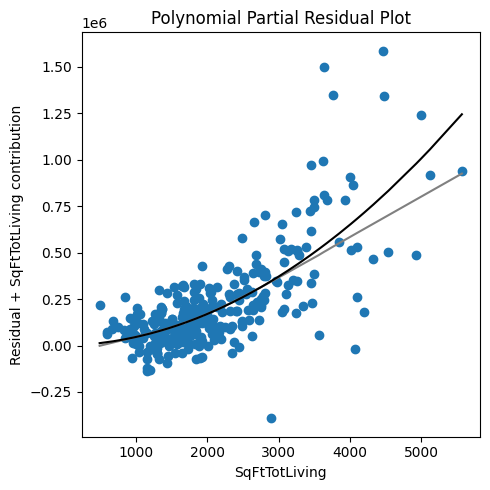

In [147]:
fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(
    result_poly, house_98105, "AdjSalePrice", "SqFtTotLiving", ax
)
ax.set_title("Polynomial Partial Residual Plot")
plt.tight_layout()
plt.show()

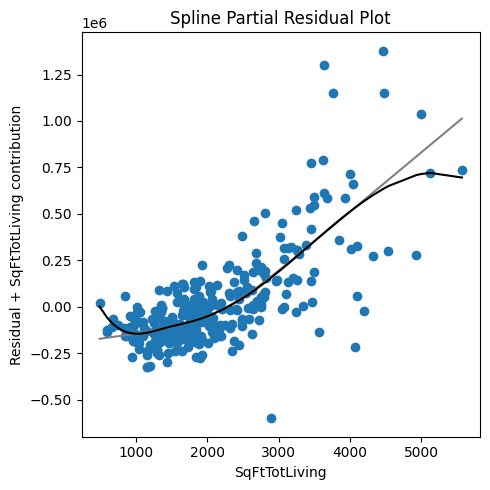

In [148]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from patsy.builtins import bs

# Ensure BSplines is removed from local context to prevent Patsy confusion
globals_dict = globals()
if 'BSplines' in globals_dict:
    del globals_dict['BSplines']

# Construct the formula
formula_spline = (
    "AdjSalePrice ~ bs(SqFtTotLiving, df=6, degree=3) + "
    "SqFtLot + Bathrooms + Bedrooms + BldgGrade"
)

# Fit the spline model safely
model_spline = smf.ols(formula=formula_spline, data=house_98105)
result_spline = model_spline.fit()

# Generate the plot
fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(
    result_spline, house_98105, "AdjSalePrice", "SqFtTotLiving", ax
)
ax.set_title("Spline Partial Residual Plot")
plt.tight_layout()
plt.show()

GENERALIZED ADDITIVE MODELS (GAM)

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


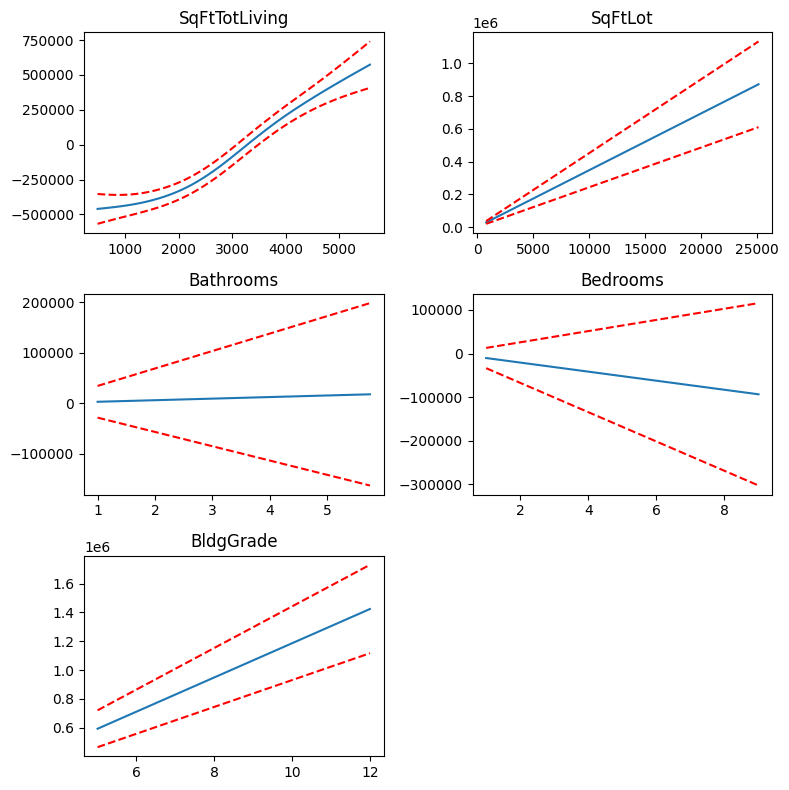

In [149]:
X_gam = house_98105[predictors_diag].values
y_gam = house_98105[outcome]

gam = LinearGAM(s(0, n_splines=12) + l(1) + l(2) + l(3) + l(4))
gam.gridsearch(X_gam, y_gam)

fig, axes = plt.subplots(figsize=(8, 8), ncols=2, nrows=3)
titles = ["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade"]

for i, title_name in enumerate(titles):
    ax = axes[i // 2, i % 2]
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.plot(
        XX[:, i],
        gam.partial_dependence(term=i, X=XX, width=0.95)[1],
        c="r",
        ls="--",
    )
    ax.set_title(title_name)

axes[2][1].set_visible(False)
plt.tight_layout()
plt.show()

REGULARIZATION: LASSO REGRESSION

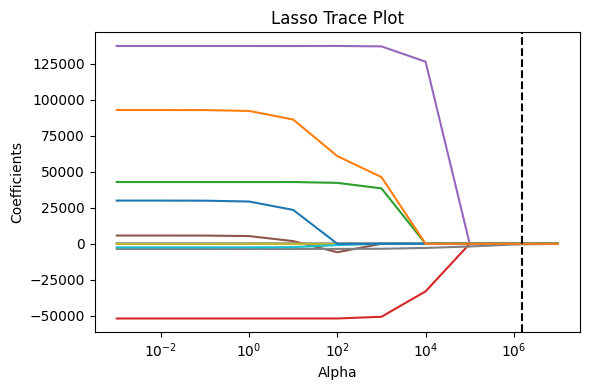


=== Optimal Lasso Coefficients (LassoCV) ===
Optimal Alpha: 1533633.0735
                       Feature        Coef
0                SqFtTotLiving  289.048846
1                      SqFtLot    0.029471
2                    Bathrooms    0.000000
3                     Bedrooms   -0.000000
4                    BldgGrade    0.000000
5               NbrLivingUnits   -0.000000
6              SqFtFinBasement    3.316479
7                      YrBuilt   -0.000000
8                  YrRenovated   45.727472
9              NewConstruction   -0.000000
10  PropertyType_Single Family   -0.000000
11      PropertyType_Townhouse    0.000000


In [150]:
X_lasso = pd.get_dummies(house[full_predictors], drop_first=True)
X_lasso["NewConstruction"] = [
    1 if nc else 0 for nc in X_lasso["NewConstruction"]
]
y_lasso = house[outcome]
columns_lasso = X_lasso.columns

alpha_values = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100,
    1000,
    10000,
    100000,
    1000000,
    10000000,
]
results_lasso = []

for alpha_val in alpha_values:
    model_l = Lasso(alpha=alpha_val, max_iter=10000)
    model_l.fit(X_lasso, y_lasso)
    results_lasso.append(model_l.coef_)

model_cv = LassoCV(cv=5, max_iter=10000)
model_cv.fit(X_lasso, y_lasso)

fig, ax = plt.subplots(figsize=(6, 4))
pd.DataFrame(results_lasso, index=alpha_values, columns=columns_lasso).plot(
    logx=True, legend=False, ax=ax
)
ax.axvline(model_cv.alpha_, color="black", linestyle="--")
ax.set_xlabel("Alpha")
ax.set_ylabel("Coefficients")
ax.set_title("Lasso Trace Plot")
plt.tight_layout()
plt.show()

print("\n=== Optimal Lasso Coefficients (LassoCV) ===")
print(f"Optimal Alpha: {model_cv.alpha_:.4f}")
print(pd.DataFrame({"Feature": columns_lasso, "Coef": model_cv.coef_}))